In [ ]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [ ]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

In [ ]:
import keras
from keras import layers

Takes a single input of shape (32,) (i.e. 32 features)
Passes it through two Dense layers (64 units, then 32 units), both ReLU
Outputs a single value (regression — no activation)

In [ ]:
# inputs = keras.Input(shape=(32,), name="my_input")
# feature1 = layers.Dense(64, activation='relu')(inputs)
# feature2 = layers.Dense(32, activation='relu')(feature1)
# outputs = layers.Dense(1)(feature2)
# model = keras.Model(inputs = inputs, outputs = outputs, name="my_functional_model")


Multi-input. Write me a model that:

Takes two separate inputs: one of shape (16,) and one of shape (8,)
Passes each through its own Dense layer (any size, ReLU)
Merges them into a single stream
Outputs a single value (regression)

In [ ]:
names = keras.Input(shape=(16,), name="names")
surnames = keras.Input(shape=(8,), name="surnames")

feature1 = layers.Dense(64, activation='relu', name="names_feature")(names)
feature2 = layers.Dense(64, activation='relu',name="surnames_feature")(surnames)

full_features = layers.Concatenate()([feature1, feature2])

outputs = layers.Dense(1)(full_features)

model = keras.Model(inputs=[names, surnames], outputs=outputs, name="my_functional_model")

keras.utils.plot_model(model, "model_x.png", show_layer_names=True)


Multi-output. Write me a model that:

Takes a single input of shape (32,)
Passes it through two Dense layers (64 then 32, ReLU) — a shared backbone
Has two outputs: one for regression (single value), one for binary classification (single value, sigmoid)

In [ ]:
names = keras.Input(shape=(32,))

feature1 = layers.Dense(64, activation='relu')(names)
feature2 = layers.Dense(32, activation='relu')(feature1)

output1 = layers.Dense(1)(feature2)
output2 = layers.Dense(1, activation='sigmoid')(feature2)

model = keras.Model(inputs=names, outputs=[output1, output2], name="my_functional_model")

keras.utils.plot_model(model, "model_xyz.png", show_layer_names=True)


 Shared layers — same exercise as before:

Two inputs, both shape (16,)
Same Dense layer applied to both
Concatenate results
Single regression output

In [ ]:
x = keras.Input(shape=(16,))
y = keras.Input(shape=(16,))

shared_dense = layers.Dense(32, activation='relu')  # created once

feature_x = shared_dense(x)
feature_y = shared_dense(y)

full_features = layers.Concatenate()([feature_x, feature_y])

output = layers.Dense(1)(full_features)


model_sh = keras.Model(inputs=[x,y], outputs=output, name="my_functional_model")

keras.utils.plot_model(model_sh, "model_sh.png", show_layer_names=True)




 Build me a single model that uses:

Two inputs: title of shape (16,) and body of shape (64,)
A shared Dense layer (32, ReLU) applied to both
The results concatenated
Two outputs: one regression, one binary classification

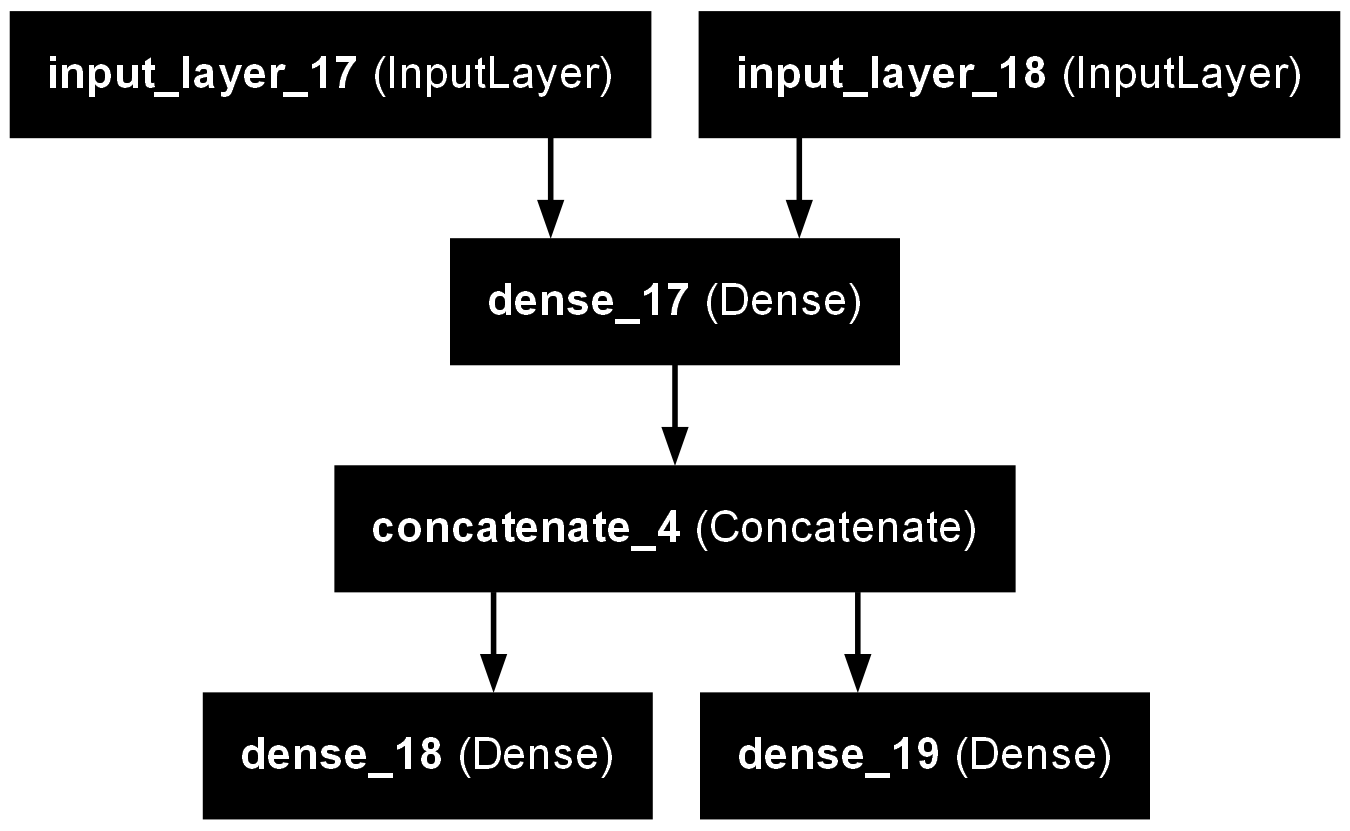

In [15]:
title = keras.Input(shape=(64,))
body = keras.Input(shape=(64,))

shared_dense = layers.Dense(64, activation='relu')

feature_title = shared_dense(title)
feature_body = shared_dense(body)

full_features = layers.Concatenate()([feature_title, feature_body])

regression_output = layers.Dense(1)(full_features)
binary_output = layers.Dense(1, activation='sigmoid')(full_features)

model_sh = keras.Model(inputs=[title, body], outputs=[regression_output, binary_output], name="my_functional_model")

keras.utils.plot_model(model_sh, "model_sh.png", show_layer_names=True)

Write me a basic training loop — don't worry about getting it perfect. Just try to express the four steps in code:

Forward pass
Compute loss
Backward pass (gradients)
Update weights

Assume you have:

model — a Keras model already built
optimizer = keras.optimizers.Adam()
loss_fn = keras.losses.MeanSquaredError()
x_batch, y_batch — one batch of data

In [ ]:
# INSIDE the tape — being recorded
predictions = model(x_batch, training=True)  # run data through model
loss = loss_fn(y_batch, predictions)          # how wrong were we?

# OUTSIDE the tape — use the recording
gradients = tape.gradient(loss, model.trainable_weights)  # how did each weight contribute to the loss?
optimizer.apply_gradients(zip(gradients, model.trainable_weights))  # nudge each weight accordingly

In [ ]:
with tf.GradientTape() as tape:
    predictions = model(x_batch, training=True)
    loss = loss_fn(y_batch, predictions)

In [ ]:
with tf.GradientTape() as tape:
    predictions = model(x_batch, training=True)  # step 1
    loss = loss_fn(y_batch, predictions)          # step 2

gradients = tape.gradient(loss, model.trainable_weights)  # step 3
optimizer.apply_gradients(zip(gradients, model.trainable_weights))  # step 4

dataset — iterable that yields (x_batch, y_batch) pairs
epochs = 10

In [ ]:
epochs = 10

for epoch in range(epochs):
    for x_batch, y_batch in dataset:
        with tf.GradientTape() as tape:
            predictions = model(x_batch, training=True)  # step 1
            loss = loss_fn(y_batch, predictions)          # step 2
    gradients = tape.gradient(loss, model.trainable_weights)  # step 3
    optimizer.apply_gradients(zip(gradients, model.trainable_weights))  # step 4

